## EDA Analysis of Abalone Dataset Before Production Code


In [4]:
import pandas as pd
import numpy as np

In [19]:
column_names = ["Sex", "Length", "Diameter", "Height", "Whole weight", "Shucked Weight", "Viscera weight", "Shell weight", "Rings"]

df = pd.read_csv("../data/abalone.data", header=None, names=column_names)
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [20]:
df.shape

(4177, 9)

In [21]:
df.dtypes

Sex                   str
Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Shucked Weight    float64
Viscera weight    float64
Shell weight      float64
Rings               int64
dtype: object

In [22]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [25]:
print(df.isna().sum())
print(df.duplicated().sum())
numeric_cols = ["Length" ,"Diameter",	"Height",	"Whole weight",	"Shucked Weight",	"Viscera weight",	"Shell weight",	"Rings"]
print((df[numeric_cols] < 0).sum())
df[df["Height"]==0]

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked Weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64
0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked Weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64


,Sex,Length,Diameter,Height,Whole weight,Shucked Weight,Viscera weight,Shell weight,Rings
1257,I,0.430,0.34,0.0,0.428,0.2065,0.0860,0.1150,8
3996,I,0.315,0.23,0.0,0.134,0.0575,0.0285,0.3505,6


### Drop 0 Height Samples, physically Implausible 

In [26]:
df = df[df["Height"]!=0].reset_index(drop = True)
df.shape

(4175, 9)

## Univariate Behaviour

Matplotlib is building the font cache; this may take a moment.


array([[<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Diameter'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Whole weight'}>,
        <Axes: title={'center': 'Shucked Weight'}>,
        <Axes: title={'center': 'Viscera weight'}>],
       [<Axes: title={'center': 'Shell weight'}>,
        <Axes: title={'center': 'Rings'}>, <Axes: >]], dtype=object)

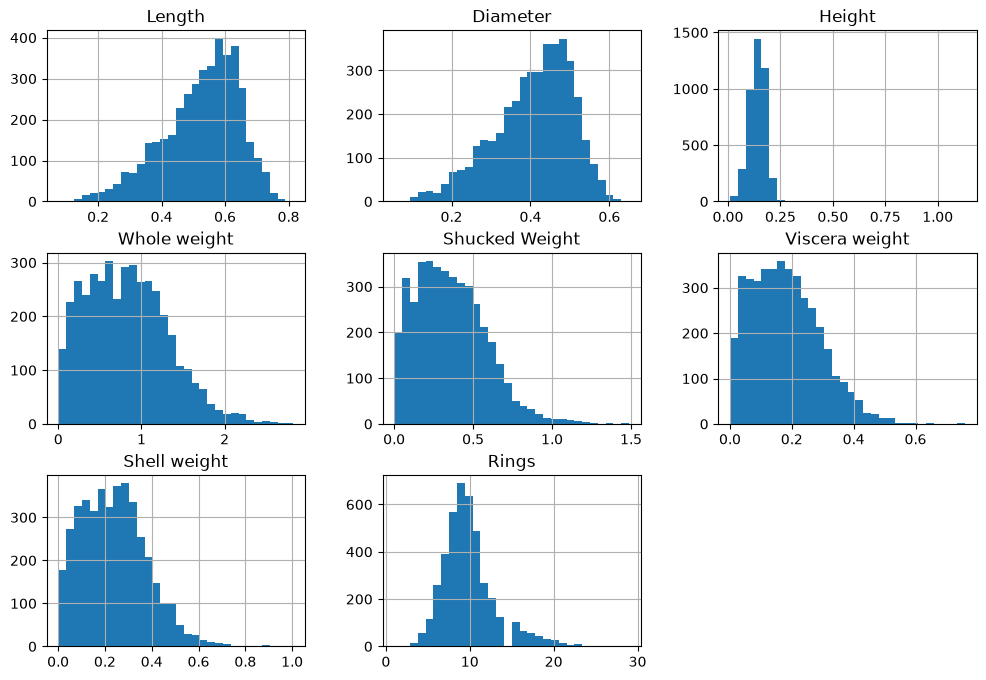

In [28]:
df[column_names].hist(figsize=(12,8), bins=30)

In [29]:
df[numeric_cols].skew()

Length           -0.640993
Diameter         -0.610182
Height            3.166364
Whole weight      0.530549
Shucked Weight    0.718735
Viscera weight    0.591455
Shell weight      0.621081
Rings             1.113754
dtype: float64

### Finding Outliers